In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle
import pandas as pd

In [2]:
   #for dataset insurance

insurance_data=pd.read_csv("insurance.csv")
y=insurance_data["charges"]
X=insurance_data.drop(columns=["charges"])
X.dtypes
variable=['sex','smoker','region']

#do one-hot encoding
X=pd.get_dummies(data=X,prefix=variable,columns=variable)
X.columns

Index(['age', 'bmi', 'children', 'sex_female', 'sex_male', 'smoker_no',
       'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [3]:
   #for dataset Housing 

#house_data=pd.read_csv('Housing.csv')
#y=house_data["price"]
#X=house_data.drop(columns=["price","id","date","condition"])
#print(X.shape)

In [4]:
#scaler=StandardScaler()
#X=scaler.fit_transform(X)


In [8]:

x_train,x_val,y_train,y_val=train_test_split(X,y,test_size=0.4,random_state=55)


#scale train and test data
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_val=scaler.transform(x_val)



In [9]:
min_split_size=[10,20,100,20,300,400,500,600,700]


In [10]:
r2_train=[]
r2_val=[]
#choose best min split size in randomforest
for min_split in min_split_size:
    model=RandomForestRegressor(min_samples_split=min_split,random_state=1234).fit(x_train,y_train)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    acc_train=r2_score(y_train,y_train_predict)
    acc_val=r2_score(y_val,y_val_predict)
    r2_train.append(acc_train)
    r2_val.append(acc_val)


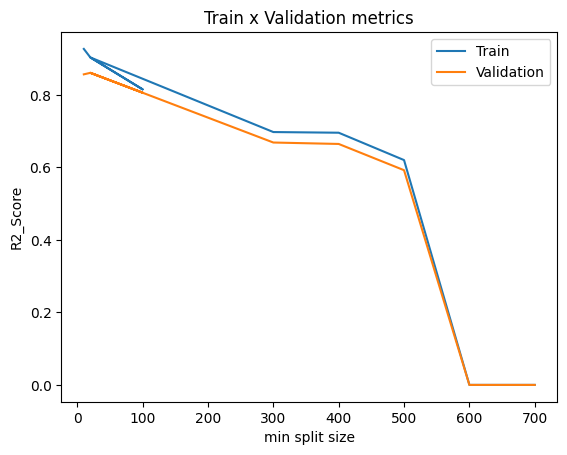

In [11]:
plt.plot(min_split_size,r2_train)
plt.plot(min_split_size,r2_val)
plt.ylabel('R2_Score')
plt.xlabel('min split size')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [12]:
index=np.argmax(r2_val)
min_split=min_split_size[index]
min_split

20

In [15]:
max_depth_size=[2,4,8,16,32,64,None]
r2_train_list=[]
r2_val_list=[]

for max_depth in max_depth_size:
    model=RandomForestRegressor(max_depth=max_depth,min_samples_split=min_split,random_state=55).fit(X,y)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    r2_train=r2_score(y_train,y_train_predict)
    r2_val=r2_score(y_val,y_val_predict)
    r2_train_list.append(r2_train)
    r2_val_list.append(r2_val)

    

/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Rand

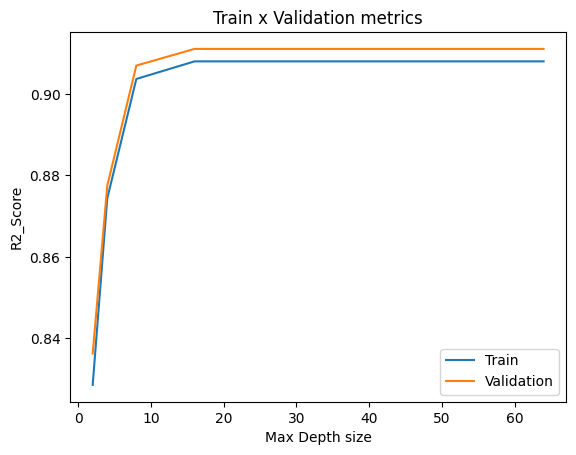

In [13]:
plt.plot(max_depth_size,r2_train_list)
plt.plot(max_depth_size,r2_val_list)
plt.ylabel('R2_Score')
plt.xlabel('Max Depth size')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [11]:
index_depth=np.argmax(r2_val_list)
max_depth=max_depth_size[index_depth]
max_depth

16

In [12]:
n_estimator_list=[10,100,200,300,400]
r2_train_list=[]
r2_val_list=[]

for n_estimator in n_estimator_list:
    model=RandomForestRegressor(n_estimators=n_estimator,max_depth=max_depth,min_samples_split=min_split,random_state=55).fit(X,y)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    r2_train=r2_score(y_train,y_train_predict)
    r2_val=r2_score(y_val,y_val_predict)
    r2_train_list.append(r2_train)
    r2_val_list.append(r2_val)


/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Rand

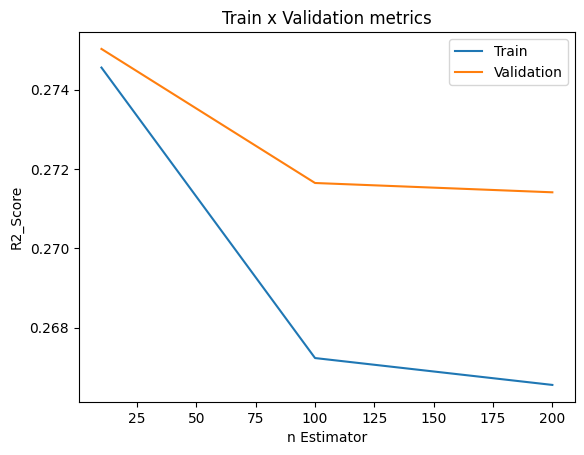

In [13]:
plt.plot(n_estimator_list,r2_train_list)
plt.plot(n_estimator_list,r2_val_list)
plt.xlabel
plt.ylabel('R2_Score')
plt.xlabel('n Estimator')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [14]:
index_opt_estimator=np.argmax(r2_val_list)

In [15]:
opt_estimator=n_estimator_list[index_opt_estimator]

In [16]:
randomforest_optimal_parameter=[opt_estimator,min_split,max_depth]

In [17]:
randomforest_optimal_parameter

[10, 20, 16]

In [18]:
insurance_model=RandomForestRegressor(n_estimators=n_estimator,max_depth=max_depth,min_samples_split=min_split,random_state=55).fit(x_train,y_train)

In [19]:
 acpickle.dump(insurance_model,open("insurance_RandomForestRegressor.pkl","wb"))